# EDA Retail Business Analysis CASE STUDY 


# Business Problem Statement

### A retail company sells different products like groceries, electronics, toys, and clothing across multiple cities in India.
- The company wants to understand:
- Which products sell more ?
- Which regions give more profit ?
- How discounts affect profit ?
- How do customers prefer to pay ?


# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Downloads\Ecommerce_Sales_Data_2024_2025.csv")

In [4]:
df

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,2024-06-25,Nishith Kulkarni,East,Kolkata,Books,Fiction,Fiction Veritatis,3,60671,0,182013.0,11853.15,Debit Card
4996,14997,2024-12-22,Aaina Chander,North,Jaipur,Toys,Doll,Doll Nulla,5,70048,0,350240.0,31237.23,Credit Card
4997,14998,2025-04-15,Dhanush Gara,South,Bangalore,Beauty,Lipstick,Lipstick Eaque,1,42162,15,35837.7,7827.50,Debit Card
4998,14999,2024-07-08,Divyansh Malhotra,East,Kolkata,Electronics,Smartwatch,Smartwatch Adipisci,4,13568,10,48844.8,6603.86,Credit Card


# Data Understanding 

### Before doing any analysis, answer these questions:
- How many total orders are there in the dataset?
- What is the first and last order date?
- What different regions are present?
- What different product categories are available?
- What payment methods do customers use?
- Which columns show numbers and which show text?


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   int64         
 1   Order Date     5000 non-null   datetime64[ns]
 2   Customer Name  5000 non-null   object        
 3   Region         5000 non-null   object        
 4   City           5000 non-null   object        
 5   Category       5000 non-null   object        
 6   Sub-Category   5000 non-null   object        
 7   Product Name   5000 non-null   object        
 8   Quantity       5000 non-null   int64         
 9   Unit Price     5000 non-null   int64         
 10  Discount       5000 non-null   int64         
 11  Sales          5000 non-null   float64       
 12  Profit         5000 non-null   float64       
 13  Payment Mode   5000 non-null   object        
 14  Month_Year     5000 non-null   object        
 15  Month          5000 n

In [11]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [12]:
df.shape

(5000, 14)

## 3️)  Data Cleaning 

### 1)  Are there any missing values in the dataset?

In [13]:
# Check total null values per column

df.isna().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

### 2) Are there any duplicate orders?


In [14]:
df.duplicated().sum()


np.int64(0)

### 3) Is the order date in a proper date format?

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
print(df['Order Date'])
print('-'*80)
print(df['Order Date'].dtype)

0      2024-10-19
1      2025-08-30
2      2023-11-04
3      2025-05-23
4      2025-01-19
          ...    
4995   2024-06-25
4996   2024-12-22
4997   2025-04-15
4998   2024-07-08
4999   2024-02-04
Name: Order Date, Length: 5000, dtype: datetime64[ns]
--------------------------------------------------------------------------------
datetime64[ns]


### 4) Are there any orders with:
- Quantity equal to zero?
- Discount less than zero?


In [16]:
len(df[df["Quantity"]==0])

0

In [17]:
df[df["Discount"]<0]

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode


### 5) Are region and city names written consistently?


In [18]:
df["Region"].value_counts()

Region
North    1288
East     1256
West     1241
South    1215
Name: count, dtype: int64

In [19]:
df["City"].value_counts()

City
Guwahati              293
Chandigarh            276
Lucknow               261
Surat                 261
Jaipur                261
Bangalore             261
Goa                   259
Patna                 258
Chennai               252
Bhubaneswar           249
Amritsar              248
Coimbatore            245
Delhi                 242
Ahmedabad             241
Mumbai                240
Pune                  240
Ranchi                233
Hyderabad             232
Thiruvananthapuram    225
Kolkata               223
Name: count, dtype: int64

## 4️) Data Manipulation

### 1) View the first 5 orders.


In [20]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


### 2) View the last 5 orders.

In [21]:
df.tail()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
4995,14996,2024-06-25,Nishith Kulkarni,East,Kolkata,Books,Fiction,Fiction Veritatis,3,60671,0,182013.0,11853.15,Debit Card
4996,14997,2024-12-22,Aaina Chander,North,Jaipur,Toys,Doll,Doll Nulla,5,70048,0,350240.0,31237.23,Credit Card
4997,14998,2025-04-15,Dhanush Gara,South,Bangalore,Beauty,Lipstick,Lipstick Eaque,1,42162,15,35837.7,7827.50,Debit Card
4998,14999,2024-07-08,Divyansh Malhotra,East,Kolkata,Electronics,Smartwatch,Smartwatch Adipisci,4,13568,10,48844.8,6603.86,Credit Card
4999,15000,2024-02-04,Aarush Walla,West,Goa,Clothing,Kids Wear,Kids Wear Repellat,1,76762,10,69085.8,5785.85,Net Banking


### 3) Look only at the columns related to:
- Order Date
- Category
- Sales
- Profit


In [22]:
df[['Order Date','Category','Sales','Profit']]

,Order Date,Category,Sales,Profit
0,2024-10-19,Books,68958.6,10525.09
1,2025-08-30,Groceries,33732.0,6299.66
2,2023-11-04,Kitchen,207603.2,19850.27
3,2025-05-23,Groceries,158610.0,36311.02
4,2025-01-19,Clothing,45033.3,9050.04
...,...,...,...,...
4995,2024-06-25,Books,182013.0,11853.15
4996,2024-12-22,Toys,350240.0,31237.23
4997,2025-04-15,Beauty,35837.7,7827.50
4998,2024-07-08,Electronics,48844.8,6603.86


### 4) Observe 10 random orders from the dataset.


In [23]:
df.sample(10)

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
4984,14985,2025-09-30,Inaaya Bandi,South,Chennai,Groceries,Sugar,Sugar Excepturi,4,15227,0,60908.00,8627.02,Debit Card
1531,11532,2025-05-29,Vanya Shan,North,Chandigarh,Clothing,Accessories,Accessories Deserunt,2,74359,10,133846.20,22113.85,Credit Card
4761,14762,2024-08-22,Armaan Rana,North,Chandigarh,Groceries,Spices,Spices Ea,4,73446,15,249716.40,53198.93,Net Banking
2674,12675,2025-04-15,Lagan Kata,South,Thiruvananthapuram,Electronics,Headphones,Headphones Voluptates,1,24645,0,24645.00,3160.60,Net Banking
1808,11809,2024-07-09,Neysa Baral,North,Jaipur,Toys,Doll,Doll Tempore,5,20070,10,90315.00,5812.04,Debit Card
1447,11448,2023-10-23,Kashvi Rout,South,Bangalore,Electronics,Headphones,Headphones Accusantium,5,67709,0,338545.00,81868.89,Credit Card
1973,11974,2024-09-21,Nirvi Lata,East,Guwahati,Books,Biography,Biography Accusamus,2,32510,15,55267.00,11807.32,Debit Card
3765,13766,2024-07-03,Gokul Hayer,North,Amritsar,Home Decor,Clock,Clock Voluptates,3,62531,15,159454.05,13180.19,Net Banking
34,10035,2023-12-31,Shayak Bala,South,Thiruvananthapuram,Toys,Action Figure,Action Figure Laboriosam,2,48271,20,77233.60,13625.93,Net Banking
4428,14429,2025-04-06,Vedika Grewal,East,Patna,Beauty,Face Cream,Face Cream Aliquid,5,34112,15,144976.00,19542.80,Credit Card


### 5) Look at customer name and city for the first 10 records.


In [24]:
df[['Customer Name','City']].head(10)

,Customer Name,City
0,Kashvi Varty,Bangalore
1,Advik Desai,Delhi
2,Rhea Kalla,Patna
3,Anika Sen,Kolkata
4,Akarsh Kaul,Pune
5,Vardaniya Jayaraman,Pune
6,Drishya Khare,Mumbai
7,Misha Dua,Lucknow
8,Arhaan Vala,Jaipur
9,Lavanya Hayer,Goa


## 4.2 Filtering 

### 1) Find all orders where sales are high.

In [25]:
df[df['Sales'] > 1000]

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,2024-06-25,Nishith Kulkarni,East,Kolkata,Books,Fiction,Fiction Veritatis,3,60671,0,182013.0,11853.15,Debit Card
4996,14997,2024-12-22,Aaina Chander,North,Jaipur,Toys,Doll,Doll Nulla,5,70048,0,350240.0,31237.23,Credit Card
4997,14998,2025-04-15,Dhanush Gara,South,Bangalore,Beauty,Lipstick,Lipstick Eaque,1,42162,15,35837.7,7827.50,Debit Card
4998,14999,2024-07-08,Divyansh Malhotra,East,Kolkata,Electronics,Smartwatch,Smartwatch Adipisci,4,13568,10,48844.8,6603.86,Credit Card


### 2) Find all orders from the South region.

In [26]:
df[df['Region']=='South']

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.60,10525.09,Debit Card
11,10012,2024-05-21,Nishith Kumar,South,Hyderabad,Beauty,Perfume,Perfume Itaque,3,27066,10,73078.20,16216.55,Net Banking
16,10017,2024-05-24,Ritvik Ramanathan,South,Hyderabad,Electronics,Smartwatch,Smartwatch Ad,3,52691,15,134362.05,26225.16,UPI
17,10018,2025-09-07,Darshit Sharma,South,Chennai,Groceries,Oil,Oil Odio,4,3775,10,13590.00,1234.71,Net Banking
25,10026,2024-01-13,Dhanush Vaidya,South,Chennai,Groceries,Rice,Rice Impedit,2,65756,5,124936.40,19544.76,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4977,14978,2025-01-01,Siya Brahmbhatt,South,Chennai,Kitchen,Mixer Grinder,Mixer Grinder Optio,2,31267,20,50027.20,9670.07,COD
4983,14984,2025-02-07,Tiya Kamdar,South,Hyderabad,Beauty,Face Cream,Face Cream Magnam,5,40448,5,192128.00,25187.64,UPI
4984,14985,2025-09-30,Inaaya Bandi,South,Chennai,Groceries,Sugar,Sugar Excepturi,4,15227,0,60908.00,8627.02,Debit Card
4993,14994,2025-03-22,Kavya Lalla,South,Chennai,Furniture,Sofa,Sofa Minus,3,673,0,2019.00,148.32,Credit Card


### 3) Find orders where no discount is given.

In [27]:
df[df['Discount'] == 0]

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
13,10014,2023-12-03,Amani Acharya,East,Patna,Clothing,Women's Wear,Women's Wear Optio,5,23843,0,119215.0,21029.48,UPI
26,10027,2025-04-22,Kimaya Rege,North,Lucknow,Beauty,Foundation,Foundation Illo,1,8276,0,8276.0,537.47,Net Banking
27,10028,2024-12-12,Anika Wable,East,Bhubaneswar,Furniture,Table,Table Error,3,731,0,2193.0,214.10,UPI
36,10037,2024-12-02,Prisha Gaba,West,Surat,Sports,Dumbbells,Dumbbells Quas,2,78467,0,156934.0,9444.77,Credit Card
38,10039,2025-09-30,Shaan Bala,East,Ranchi,Toys,Puzzle,Puzzle Assumenda,2,60907,0,121814.0,24378.77,COD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4979,14980,2024-09-07,Oorja Borde,East,Kolkata,Books,Non-Fiction,Non-Fiction Labore,4,60687,0,242748.0,28821.80,Debit Card
4984,14985,2025-09-30,Inaaya Bandi,South,Chennai,Groceries,Sugar,Sugar Excepturi,4,15227,0,60908.0,8627.02,Debit Card
4993,14994,2025-03-22,Kavya Lalla,South,Chennai,Furniture,Sofa,Sofa Minus,3,673,0,2019.0,148.32,Credit Card
4995,14996,2024-06-25,Nishith Kulkarni,East,Kolkata,Books,Fiction,Fiction Veritatis,3,60671,0,182013.0,11853.15,Debit Card


### 4) Find all Grocery category orders.

In [28]:
df[df['Category'] == 'Groceries']

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
8,10009,2025-03-07,Arhaan Vala,North,Jaipur,Groceries,Spices,Spices Expedita,1,40834,20,32667.2,3700.89,Credit Card
17,10018,2025-09-07,Darshit Sharma,South,Chennai,Groceries,Oil,Oil Odio,4,3775,10,13590.0,1234.71,Net Banking
21,10022,2024-03-16,Kashvi Ratti,North,Lucknow,Groceries,Wheat,Wheat Natus,5,26762,15,113738.5,27267.31,Credit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4970,14971,2024-02-20,Kiaan Sur,South,Thiruvananthapuram,Groceries,Rice,Rice Error,3,11415,10,30820.5,3916.08,Net Banking
4981,14982,2024-03-23,Ishita Subramaniam,North,Amritsar,Groceries,Wheat,Wheat Adipisci,2,79696,20,127513.6,15071.89,COD
4984,14985,2025-09-30,Inaaya Bandi,South,Chennai,Groceries,Sugar,Sugar Excepturi,4,15227,0,60908.0,8627.02,Debit Card
4990,14991,2025-01-12,Aarush Shroff,East,Ranchi,Groceries,Wheat,Wheat Tenetur,2,13640,5,25916.0,1946.69,Credit Card


### 5) Find orders where customers bought more than 2 items.

In [29]:
df[df['Quantity'] > 2]

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.20,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.00,36311.02,UPI
5,10006,2025-04-06,Vardaniya Jayaraman,West,Pune,Furniture,Chair,Chair Assumenda,5,40287,15,171219.75,23722.84,Credit Card
11,10012,2024-05-21,Nishith Kumar,South,Hyderabad,Beauty,Perfume,Perfume Itaque,3,27066,10,73078.20,16216.55,Net Banking
13,10014,2023-12-03,Amani Acharya,East,Patna,Clothing,Women's Wear,Women's Wear Optio,5,23843,0,119215.00,21029.48,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4992,14993,2025-08-18,Bhamini Sarin,North,Delhi,Groceries,Rice,Rice Neque,3,14477,10,39087.90,2939.60,Credit Card
4993,14994,2025-03-22,Kavya Lalla,South,Chennai,Furniture,Sofa,Sofa Minus,3,673,0,2019.00,148.32,Credit Card
4995,14996,2024-06-25,Nishith Kulkarni,East,Kolkata,Books,Fiction,Fiction Veritatis,3,60671,0,182013.00,11853.15,Debit Card
4996,14997,2024-12-22,Aaina Chander,North,Jaipur,Toys,Doll,Doll Nulla,5,70048,0,350240.00,31237.23,Credit Card


### 6) Find orders where profit is very low.

In [30]:
df[df['Profit'] < 0]

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode


### 7) Find all orders made in the year 2025.

In [31]:
df[df['Order Date'].dt.year == 2025]

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.00,6299.66,Debit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.00,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.30,9050.04,Debit Card
5,10006,2025-04-06,Vardaniya Jayaraman,West,Pune,Furniture,Chair,Chair Assumenda,5,40287,15,171219.75,23722.84,Credit Card
7,10008,2025-08-17,Misha Dua,North,Lucknow,Books,Biography,Biography Vel,1,15885,10,14296.50,1289.03,Debit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4990,14991,2025-01-12,Aarush Shroff,East,Ranchi,Groceries,Wheat,Wheat Tenetur,2,13640,5,25916.00,1946.69,Credit Card
4992,14993,2025-08-18,Bhamini Sarin,North,Delhi,Groceries,Rice,Rice Neque,3,14477,10,39087.90,2939.60,Credit Card
4993,14994,2025-03-22,Kavya Lalla,South,Chennai,Furniture,Sofa,Sofa Minus,3,673,0,2019.00,148.32,Credit Card
4994,14995,2025-01-06,Hunar Vaidya,North,Amritsar,Sports,Tennis Racket,Tennis Racket Omnis,1,72936,15,61995.60,5224.04,COD


## 4.3 Grouping 

### 1) Total sales for each region.

In [32]:
df.groupby('Region')['Sales'].sum()

Region
East     1.358116e+08
North    1.435782e+08
South    1.232302e+08
West     1.310460e+08
Name: Sales, dtype: float64

### 2) Total profit for each region.

In [33]:
df.groupby('Region')['Profit'].sum()

Region
East     20532558.12
North    21343004.33
South    18253049.32
West     19580123.14
Name: Profit, dtype: float64

### 3) Average sales for each category.

In [34]:
df.groupby('Category')['Sales'].mean()

Category
Beauty         110442.195000
Books          104039.096591
Clothing       107737.589628
Electronics    111415.008369
Furniture      107489.920114
Groceries      101878.942872
Home Decor     111132.470583
Kitchen        102704.360417
Sports         101897.059198
Toys           109262.272908
Name: Sales, dtype: float64

### 4) Number of orders in each category.

In [35]:
df['Category'].value_counts()

Category
Books          528
Kitchen        528
Furniture      527
Home Decor     515
Clothing       511
Sports         511
Toys           478
Electronics    472
Groceries      470
Beauty         460
Name: count, dtype: int64

### 5) Total sales by payment mode.

In [36]:
df.groupby('Payment Mode')['Sales'].sum()

Payment Mode
COD            1.088814e+08
Credit Card    1.060271e+08
Debit Card     1.053464e+08
Net Banking    1.114655e+08
UPI            1.019456e+08
Name: Sales, dtype: float64

### 6) Which city gives the highest profit?

In [37]:
df.groupby('City')['Profit'].nlargest(1)

City                    
Ahmedabad           1124    82744.41
Amritsar            1143    73960.76
Bangalore           3646    87688.21
Bhubaneswar         1234    71278.79
Chandigarh          2330    82804.05
Chennai             545     77964.03
Coimbatore          2471    86486.30
Delhi               2068    75188.15
Goa                 4556    89688.44
Guwahati            3488    72829.75
Hyderabad           3913    67265.59
Jaipur              3703    71866.56
Kolkata             3121    75212.33
Lucknow             1233    74570.86
Mumbai              1161    71420.71
Patna               1475    68446.84
Pune                2079    71314.27
Ranchi              4353    76355.62
Surat               876     67741.60
Thiruvananthapuram  2805    77192.10
Name: Profit, dtype: float64

## 5️) Data Visualization


### 5.1 Univariate Analysis

#### 1) Sales distribution – are most sales high or low?


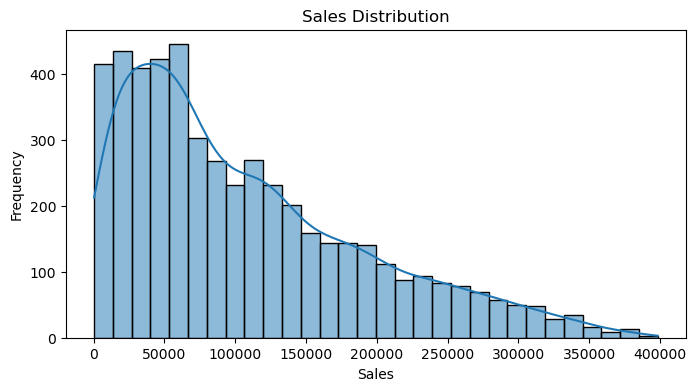

In [38]:
plt.figure(figsize = (8, 4))
sns.histplot(df['Sales'], bins = 30, kde = True)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

#### 2) Profit distribution – are profits mostly small or large?

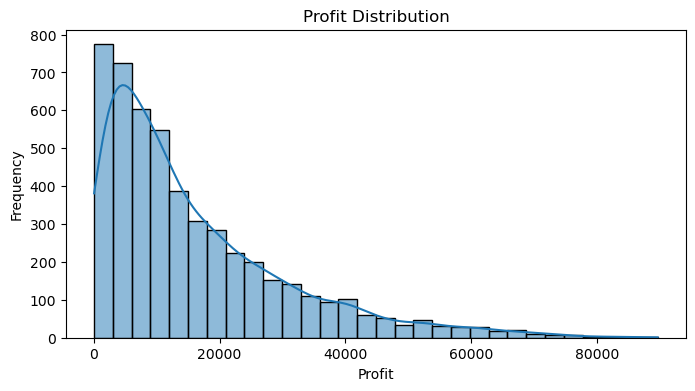

In [39]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Profit'], bins=30, kde=True)
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

#### 3) Count of orders in each category.


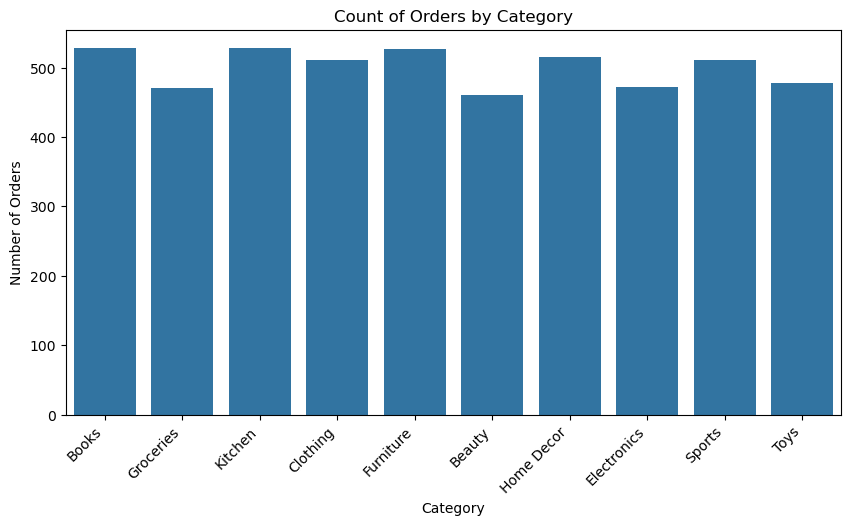

In [41]:
plt.figure(figsize=(10, 5))
sns.countplot(x='Category', data=df)
plt.title('Count of Orders by Category')
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.show()

#### 4) Most used payment method.


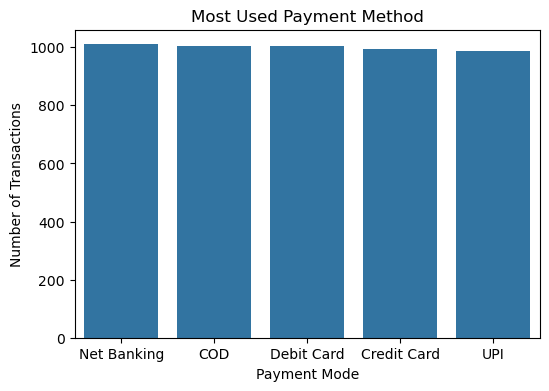

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Payment Mode', data=df, order=df['Payment Mode'].value_counts().index)
plt.title('Most Used Payment Method')
plt.xlabel('Payment Mode')
plt.ylabel('Number of Transactions')
plt.show()

#### 5) Discount values – which discount is most common?

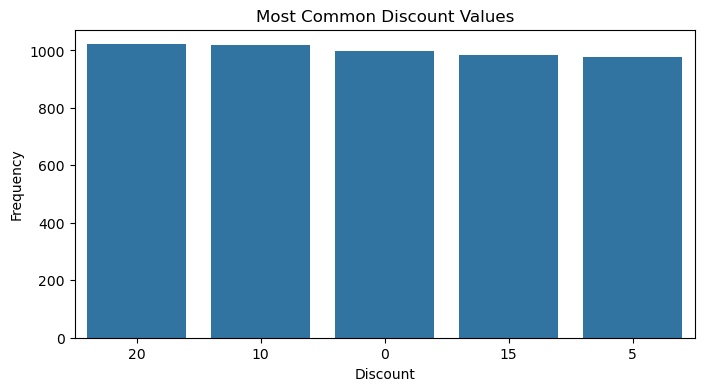

Most common discount value: 20


In [44]:
plt.figure(figsize=(8, 4))
sns.countplot(x='Discount', data=df, order=df['Discount'].value_counts().index)
plt.title('Most Common Discount Values')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.show()

print("Most common discount value:", df['Discount'].mode()[0])

## 5.2 Bivariate Analysis

### 1) Compare sales and profit.


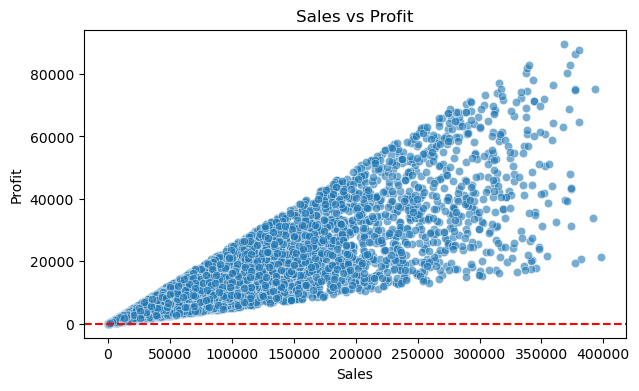

In [45]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Sales', y='Profit', data=df, alpha=0.6)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.axhline(0, color='red', linestyle='--')
plt.show()

### 2) Compare discount and profit.


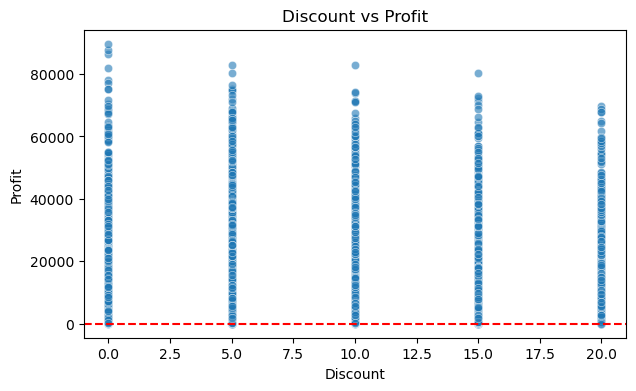

In [46]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.axhline(0, color='red', linestyle='--')
plt.show()

### 3) Compare region and total sales.

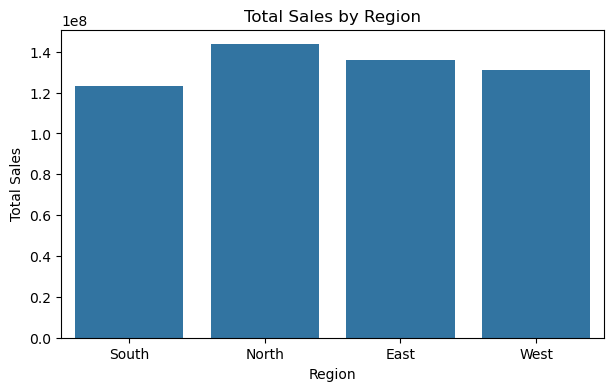

In [49]:
plt.figure(figsize=(7, 4))
sns.barplot(x='Region', y='Sales', data=df, estimator=sum, ci=None)
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

### 4) Compare category and average profit.


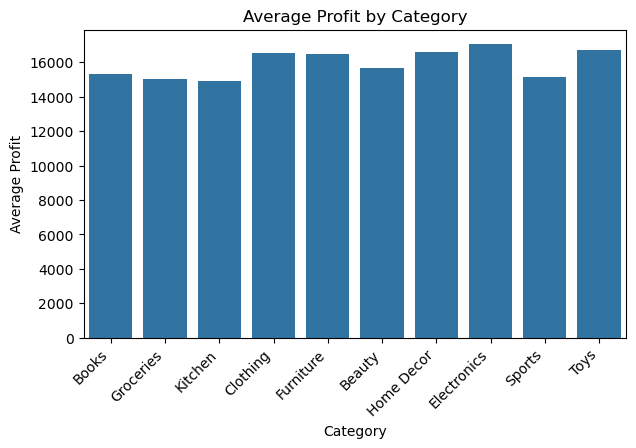

In [50]:
plt.figure(figsize=(7, 4))
sns.barplot(x='Category', y='Profit', data=df, errorbar=None)
plt.title('Average Profit by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit')
plt.xticks(rotation=45, ha='right')
plt.show()

### 5) Compare quantity and sales.


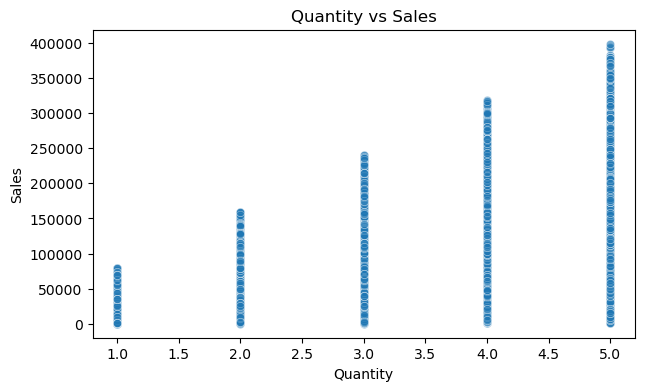

In [51]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='Quantity', y='Sales', data=df, alpha=0.6)
plt.title('Quantity vs Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')
plt.show()

## 5.3 Multivariate Analysis 

### 1) Compare category sales across different regions.


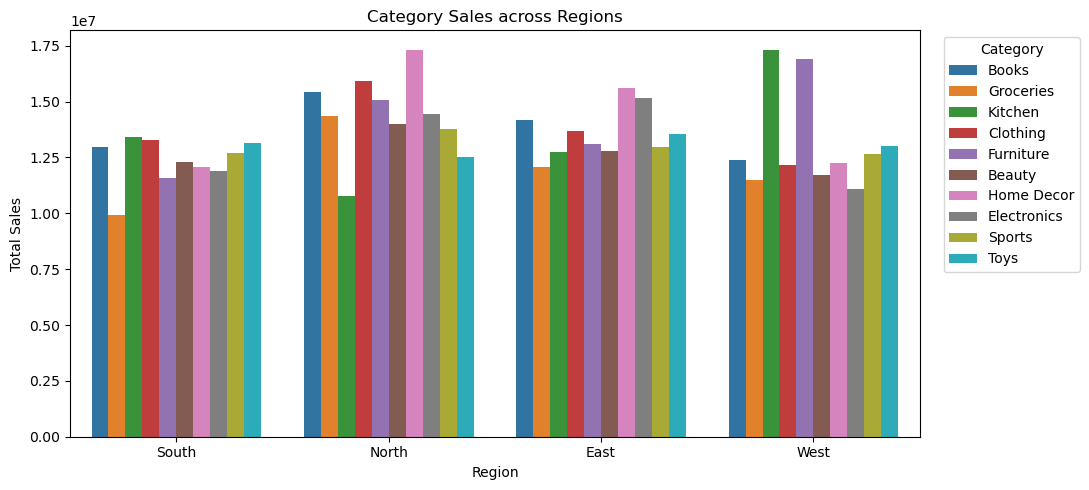

In [53]:
plt.figure(figsize=(11, 5))
sns.barplot(x='Region', y='Sales', hue='Category', data=df, estimator=sum, errorbar=None)
plt.title('Category Sales across Regions')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 2) Compare profit of categories in top cities.


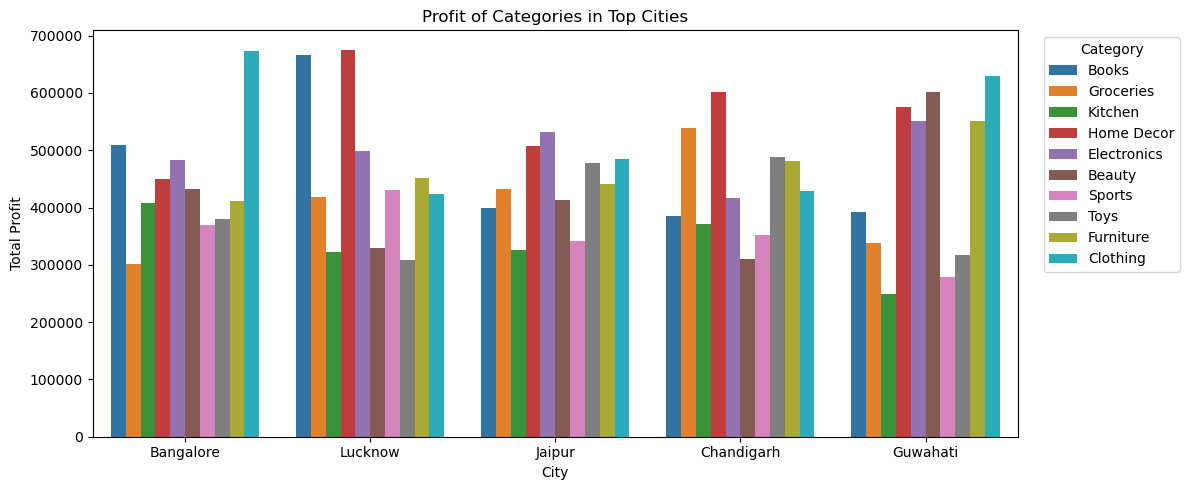

In [55]:
# 1. the top 5 cities by total profit

top_cities = df.groupby('City')['Profit'].sum().nlargest(5).index

# 2. filter data for top cities

top_cities_df = df[df['City'].isin(top_cities)]

# 3. Plot category profit across top cities

plt.figure(figsize=(12, 5))
sns.barplot(x='City', y='Profit', hue='Category', data=top_cities_df, estimator=sum, errorbar=None)
plt.title('Profit of Categories in Top Cities')
plt.xlabel('City')
plt.ylabel('Total Profit')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3) Study how discount affects profit for different categories.


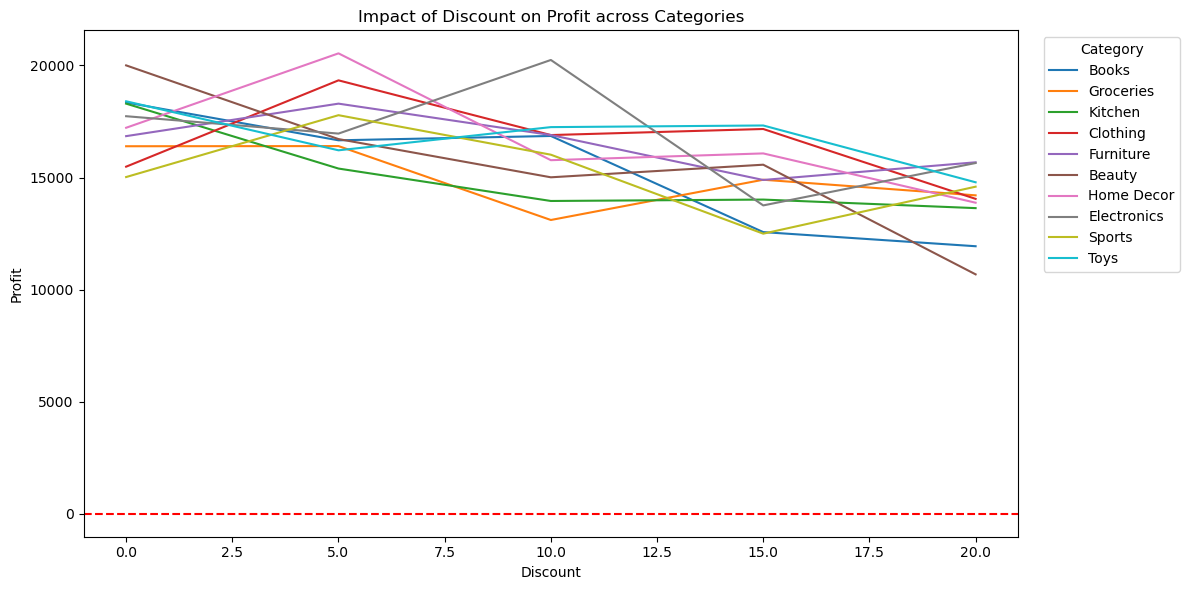

In [56]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Discount', y='Profit', hue='Category', data=df, errorbar=None)
plt.title('Impact of Discount on Profit across Categories')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.axhline(0, color='red', linestyle='--')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4) Observe sales trends over time for each category.


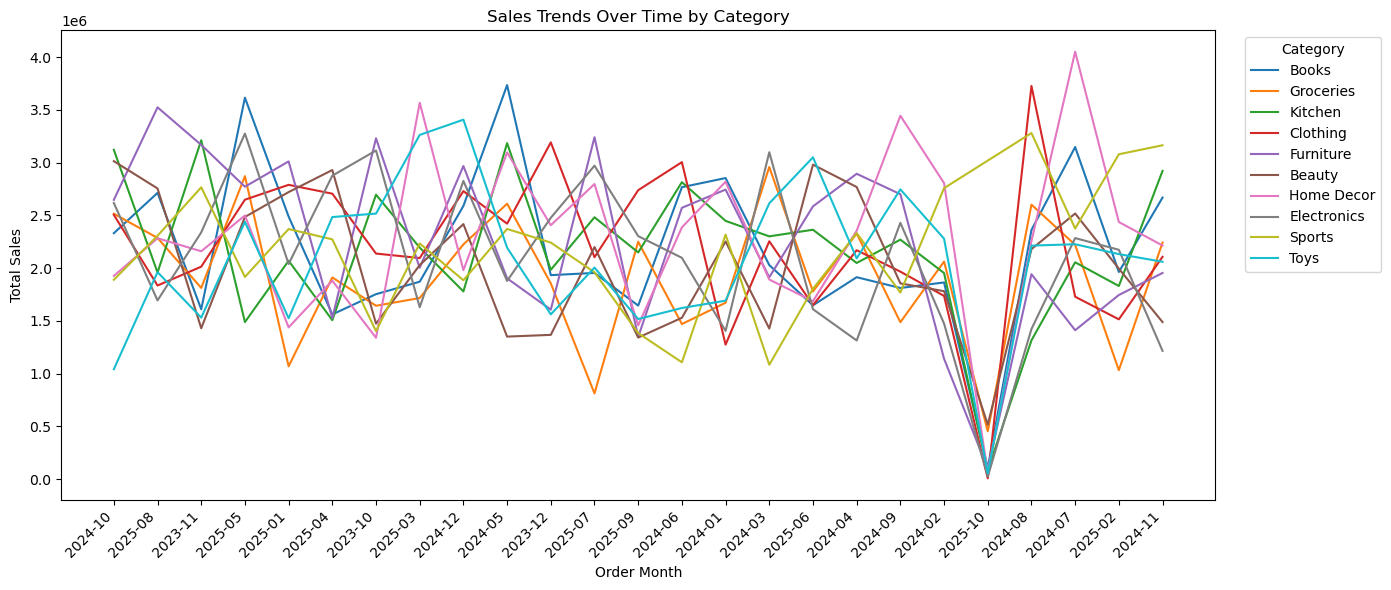

In [57]:
# 1. Ensure date column is datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'])

# 2. Extract Month-Year for clean time aggregation

df['Month_Year'] = df['Order Date'].dt.to_period('M').astype(str)

# 3. Plot sales trends over time by category

plt.figure(figsize=(14, 6))
sns.lineplot(x='Month_Year', y='Sales', hue='Category', data=df, estimator=sum, errorbar=None)
plt.title('Sales Trends Over Time by Category')
plt.xlabel('Order Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 5) What are the average monthly sales for each category?

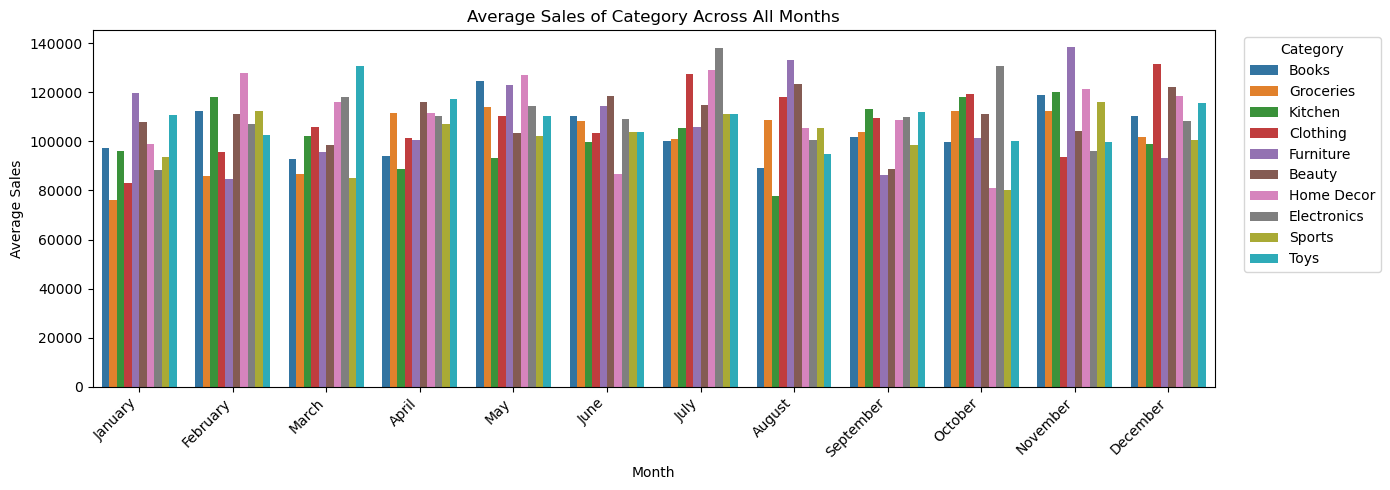

In [58]:
# 1. Extract full month name

df['Month'] = df['Order Date'].dt.month_name()

# 2. Define standard calendar order for all 12 months

months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# 3. Plot average sales by category across all months in calendar order

plt.figure(figsize=(14, 5))
sns.barplot(x='Month', y='Sales', hue='Category', data=df, order=months_order, errorbar=None)
plt.title('Average Sales of Category Across All Months')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Key Insights

### Big-Ticket Items Lead Order Value: Categories like Furniture and Electronics consistently hit higher average sales per order throughout the year. Everyday essentials like Groceries, Clothing, and Beauty see lower average order values, meaning they rely purely on purchase volume.

### Distinct Seasonal Demand: Sales aren't flat across the calendar. There are visible mid-year jumps and end-of-year peaks, showing clear customer buying cycles around holidays and sale seasons.

### Heavy Discounts Hurt the Bottom Line: Giving steep discounts is shrinking profits fast. While promotions bring in orders, high discounts frequently push net profits into the negative.

### Concentrated Revenue: A handful of top cities and specific regions generate most of the overall profit, showing where the core customer base actually lives.

# Business Recommendations

### Rethink the Discount Strategy: Stop offering blanket discounts on low-margin products. Instead of slashing 30–40% off, use bundle offers (e.g., "Buy 2, Get 10% Off") or minimum order thresholds to protect margins.

### Time Inventory Around Seasonal Surges: Stock up on popular items in Furniture, Electronics, and Home Decor right before historically proven peak months so high-demand items don't go out of stock.

### Double Down on Top Cities: Focus marketing spend and faster delivery options in the 5 most profitable cities where customers are already willing to spend more.

### Smooth Out Checkout: Promote the most popular payment methods right at checkout to reduce cart drop-offs.

# Conclusion

### The store has solid demand and healthy revenue coming from core categories, but relying too heavily on deep discounts is eating away at the actual profits. By pulling back on aggressive price cuts, focusing ad spend on top-performing cities, and planning around seasonal peaks, the business can shift from just chasing sales numbers to making genuinely profitable sales.